In [13]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

In [14]:
df = pd.read_csv("dataset/HousePrice.csv")

In [15]:
df.head(3)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1850000000,61666.67
1,60,1,True,True,True,Shahran,1850000000,61666.67
2,79,2,True,True,True,Pardis,550000000,18333.33


In [16]:
# We don't need "Address" feature!
df.drop(columns="Address",inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   int64  
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Price       3479 non-null   int64  
 6   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(1), int64(3)
memory usage: 119.0 KB


<Axes: xlabel='Price'>

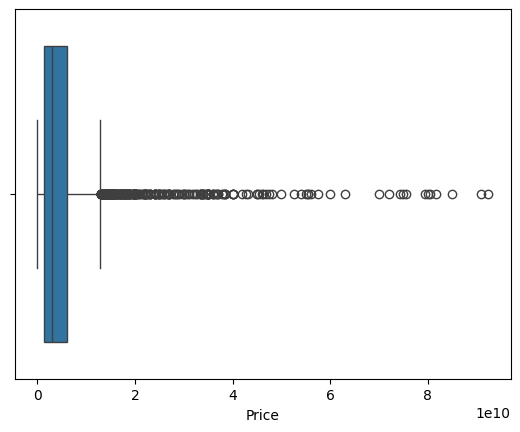

In [18]:
sns.boxplot(data=df,x="Price")

In [19]:
data = df.copy()

Q1 = data["Price"].quantile(0.25)
Q3 = data["Price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data["outlier"] = ((data["Price"] < lower_bound) | (data["Price"] > upper_bound))

data = data.loc[data["outlier"] == False]

In [20]:
data.head(3)

,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD),outlier
0,63,1,True,True,True,1850000000,61666.67,False
1,60,1,True,True,True,1850000000,61666.67,False
2,79,2,True,True,True,550000000,18333.33,False


In [63]:
parking_le = LabelEncoder()
data["Parking"] = parking_le.fit_transform(data["Parking"])

warehouse_le = LabelEncoder()
data["Warehouse"] = warehouse_le.fit_transform(data["Warehouse"])

elevator_le = LabelEncoder()
data["Elevator"] = elevator_le.fit_transform(data["Elevator"])

print(f"Parking Classes: {dict(enumerate(parking_le.classes_))}")
print(f"Warehouse Classes: {dict(enumerate(warehouse_le.classes_))}")
print(f"Elevator Classes: {dict(enumerate(elevator_le.classes_))}")

Parking Classes: {0: np.False_, 1: np.True_}
Warehouse Classes: {0: np.False_, 1: np.True_}
Elevator Classes: {0: np.False_, 1: np.True_}


In [99]:
data.columns

Index(['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Price',
       'Price(USD)', 'outlier'],
      dtype='str')

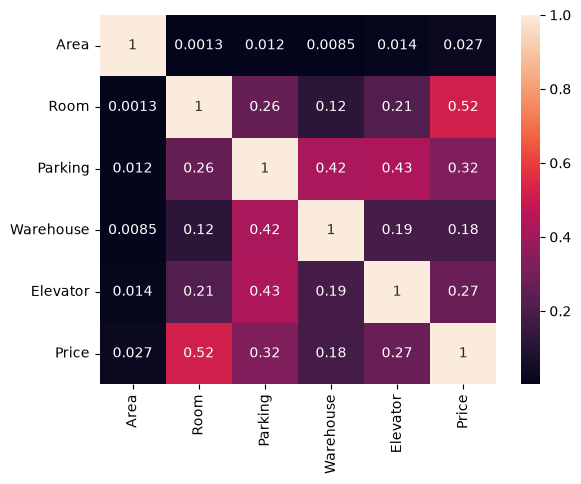

In [100]:
data_corr = data[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Price']].corr()
sns.heatmap(data_corr,annot=True)
plt.show()

In [21]:
X = data[["Area","Room","Parking","Warehouse","Elevator"]]
y = data[["Price"]]

In [193]:
x_train, x_test, y_train, y_test = train_test_split(x_scale,y,test_size=0.3,random_state=42)

scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [194]:
mlr = LinearRegression()

mlr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 5)","[[7.90e+07,1.31e+09,3.84e+08,1.40e+08,3.37e+08]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.44e+09]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[64.54,47.09,44.14,41.41,32.31]"


In [195]:
predicted_mlr_test = mlr.predict(x_test)
predicted_mlr_train = mlr.predict(x_train)

In [199]:
print(f"r2_score of test data: {r2_score(y_test,predicted_mlr_test)}")
print(f"r2_score of train data: {r2_score(y_train,predicted_mlr_train)}")

print(f"MAE: {mean_absolute_error(y_test,predicted_mlr_test)}")
print(f"MSE: {mean_squared_error(y_test,predicted_mlr_test)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test,predicted_mlr_test))}")

r2_score of test data: 0.30516189490340284
r2_score of train data: 0.3239922765299288
MAE: 1839185229.5365093
MSE: 5.788696760487596e+18
RMSE: 2405971063.9339776
